# Synthetic Data Sanity Check

Visual inspection of generated occupancy patterns:
1. Time-of-day curves (student vs. employee)
2. Day-of-week variation
3. Academic period effects
4. Campus closures
5. Lot popularity spread
6. Noise distribution

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_PATH = "../data/synthetic_occupancy_snapshot.parquet"

df = pd.read_parquet(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["time_decimal"] = df["hour"] + df["minute"] / 60
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["date"] = df["timestamp"].dt.date
df["lot_type"] = df["lot_id"].apply(
    lambda x: "Employee" if x.startswith("E") else "Student"
)

print(f"{len(df):,} rows, {df['lot_id'].nunique()} lots")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
df.head()

245,616 rows, 28 lots
Date range: 2025-08-17 to 2025-12-23


,lot_id,timestamp,occupancy,available,occupancy_rate,confidence,is_cold_start,academic_period,week_of_semester,is_campus_open,hour,minute,time_decimal,day_of_week,date,lot_type
0,G2,2025-08-17 06:00:00+00:00,4,421,0.0099,HIGH,True,off_session,0,True,6,0,6.00,6,2025-08-17,Student
1,G2,2025-08-17 06:15:00+00:00,0,425,0.0000,HIGH,True,off_session,0,True,6,15,6.25,6,2025-08-17,Student
2,G2,2025-08-17 06:30:00+00:00,6,419,0.0130,HIGH,True,off_session,0,True,6,30,6.50,6,2025-08-17,Student
3,G2,2025-08-17 06:45:00+00:00,13,412,0.0305,HIGH,True,off_session,0,True,6,45,6.75,6,2025-08-17,Student
4,G2,2025-08-17 07:00:00+00:00,0,425,0.0000,HIGH,True,off_session,0,True,7,0,7.00,6,2025-08-17,Student


## Time-of-Day Curves

Student lots should peak around 12-1pm, employee lots should peak 9am-12pm and drop off sharply at 4-5pm.

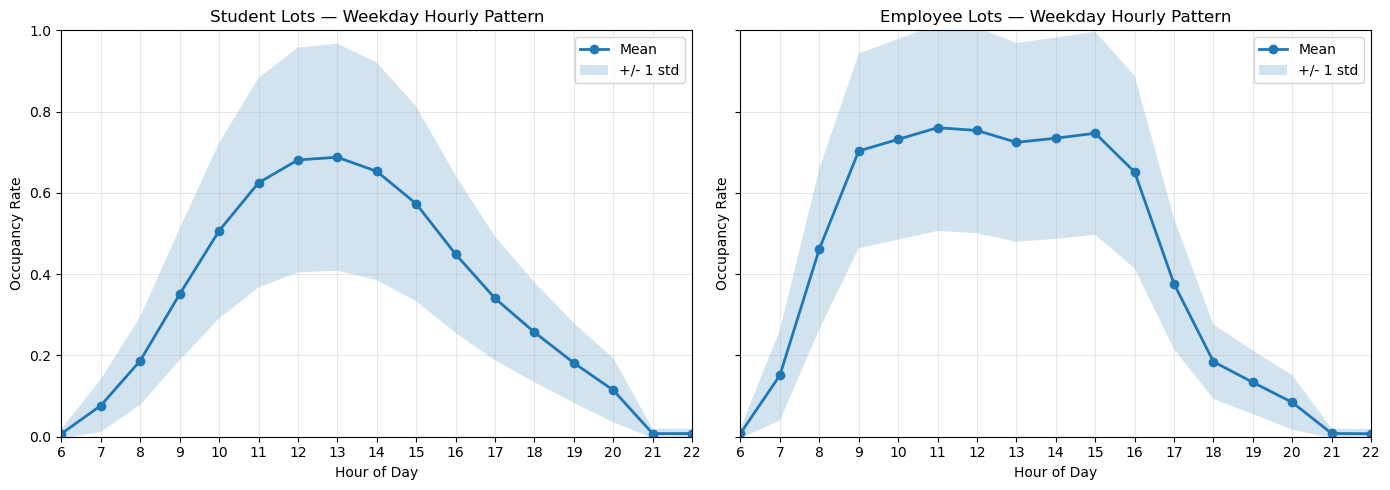

In [2]:
weekday = df[df["day_of_week"] <= 4]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lot_type in zip(axes, ["Student", "Employee"]):
    subset = weekday[weekday["lot_type"] == lot_type]
    hourly = subset.groupby("hour")["occupancy_rate"].agg(["mean", "std"])

    ax.plot(hourly.index, hourly["mean"], "o-", linewidth=2, label="Mean")
    ax.fill_between(
        hourly.index,
        hourly["mean"] - hourly["std"],
        hourly["mean"] + hourly["std"],
        alpha=0.2,
        label="+/- 1 std",
    )
    ax.set_title(f"{lot_type} Lots — Weekday Hourly Pattern")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Occupancy Rate")
    ax.set_xlim(6, 22)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend()
plt.tight_layout()
plt.show()

## Day-of-Week Variation

Weekdays should be higher than weekends. Friday slightly lower for student lots.
Notes:
- If generated data span for a single semester, the sample size for finals and breaks is smaller and the peak and dip will seem dramatic.

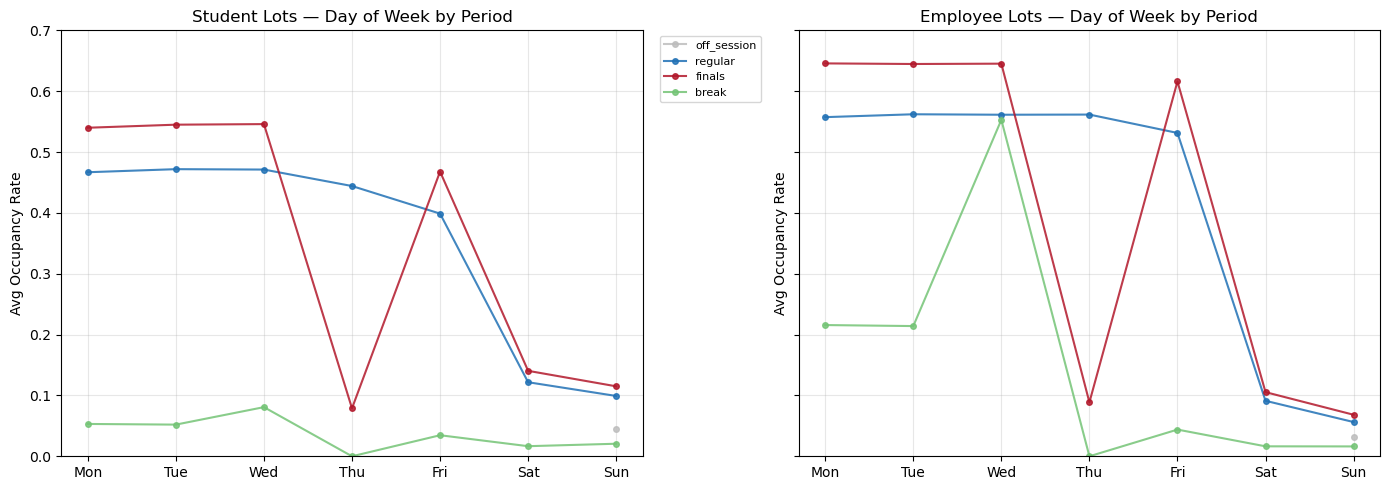

In [3]:
operating = df[(df["hour"] >= 7) & (df["hour"] < 21)]
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

period_order = [
    "off_session",
    "orientation",
    "first_two_weeks",
    "regular",
    "midterms",
    "finals_prep",
    "finals",
    "break",
    "intersession",
]
period_order = [p for p in period_order if p in operating["academic_period"].unique()]

period_colors = {
    "off_session": "#bdbdbd",
    "orientation": "#9ecae1",
    "first_two_weeks": "#6baed6",
    "regular": "#2171b5",
    "midterms": "#f4a582",
    "finals_prep": "#d6604d",
    "finals": "#b2182b",
    "break": "#74c476",
    "intersession": "#c7e9c0",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lot_type in zip(axes, ["Student", "Employee"]):
    subset = operating[operating["lot_type"] == lot_type]

    for period in period_order:
        period_data = subset[subset["academic_period"] == period]
        dow_avg = period_data.groupby("day_of_week")["occupancy_rate"].mean()
        ax.plot(
            dow_avg.index,
            dow_avg.values,
            "o-",
            label=period,
            color=period_colors.get(period, "gray"),
            linewidth=1.5,
            markersize=4,
            alpha=0.85,
        )

    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_title(f"{lot_type} Lots — Day of Week by Period")
    ax.set_ylabel("Avg Occupancy Rate")
    ax.set_ylim(0, 0.7)

axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Lot Popularity Spread

High-demand lots (G1, PYR, etc.) should have higher avg occupancy than low-demand lots (G8, G9, G11).

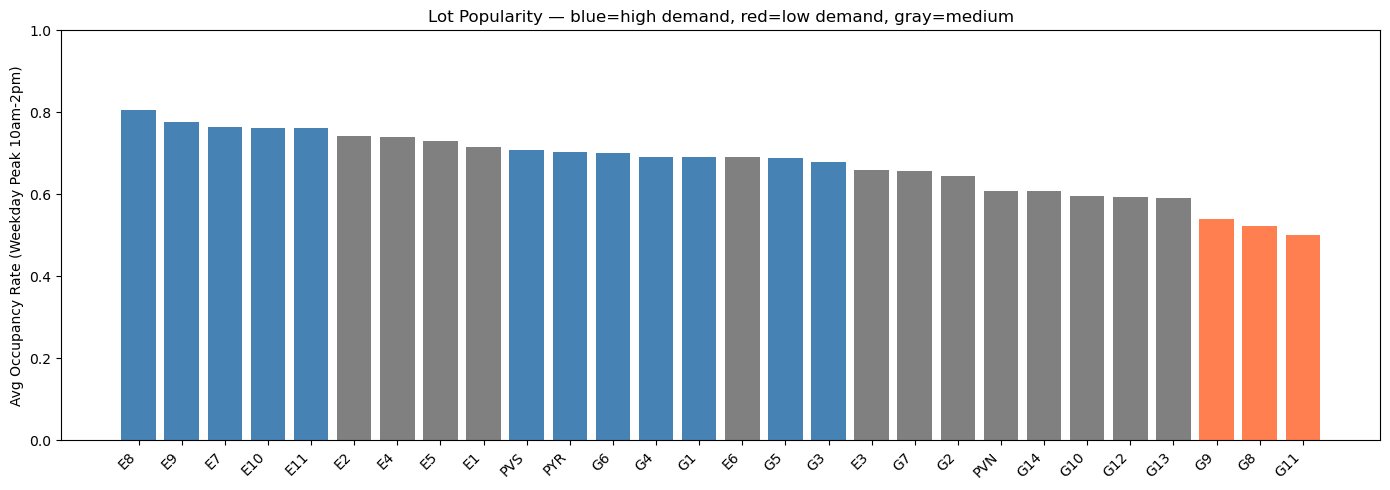

In [4]:
weekday_peak = df[(df["day_of_week"] <= 4) & (df["hour"].between(10, 14))]

lot_avg = (
    weekday_peak.groupby("lot_id")["occupancy_rate"].mean().sort_values(ascending=False)
)

HIGH_DEMAND = {
    "E7",
    "E8",
    "E9",
    "E10",
    "E11",
    "G1",
    "G3",
    "G4",
    "G5",
    "G6",
    "PVS",
    "PYR",
}
LOW_DEMAND = {"G8", "G9", "G11"}

colors = []
for lot in lot_avg.index:
    if lot in HIGH_DEMAND:
        colors.append("steelblue")
    elif lot in LOW_DEMAND:
        colors.append("coral")
    else:
        colors.append("gray")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(lot_avg)), lot_avg.values, color=colors)
ax.set_xticks(range(len(lot_avg)))
ax.set_xticklabels(lot_avg.index, rotation=45, ha="right")
ax.set_ylabel("Avg Occupancy Rate (Weekday Peak 10am-2pm)")
ax.set_title("Lot Popularity — blue=high demand, red=low demand, gray=medium")
ax.set_ylim(0, 1)
ax.grid(False)

plt.tight_layout()
plt.show()

## Noise Distribution
Graph residuals from lot+hour+day+period means.
- Exclude the raw generator noise (~0.07 std)

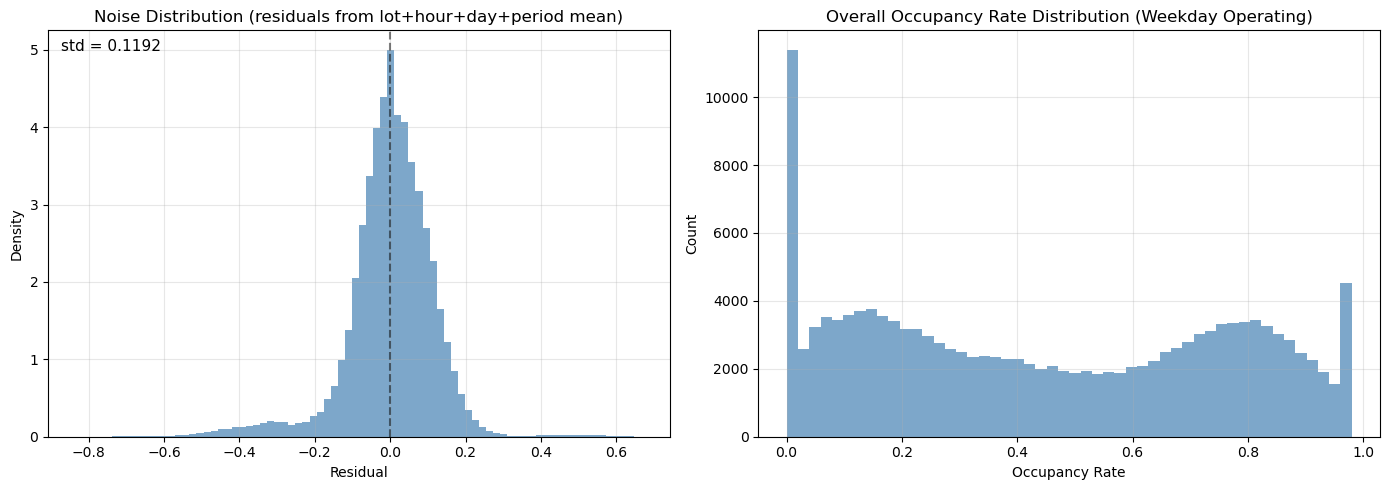

In [5]:
weekday_operating = df[
    (df["day_of_week"] <= 4) & (df["hour"] >= 7) & (df["hour"] < 21)
].copy()

# Compute residual from lot+hour+day+period mean to isolate pure noise
group_mean = weekday_operating.groupby(
    ["lot_id", "hour", "day_of_week", "academic_period"]
)["occupancy_rate"].transform("mean")
weekday_operating["residual"] = weekday_operating["occupancy_rate"] - group_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    weekday_operating["residual"], bins=80, density=True, alpha=0.7, color="steelblue"
)
axes[0].set_title("Noise Distribution (residuals from lot+hour+day+period mean)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Density")

std = weekday_operating["residual"].std()
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[0].text(0.02, 0.95, f"std = {std:.4f}", transform=axes[0].transAxes, fontsize=11)

# Occupancy rate distribution overall
axes[1].hist(weekday_operating["occupancy_rate"], bins=50, alpha=0.7, color="steelblue")
axes[1].set_title("Overall Occupancy Rate Distribution (Weekday Operating)")
axes[1].set_xlabel("Occupancy Rate")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Heatmap — Hour x Day of Week

Quick overview of the full weekly pattern.

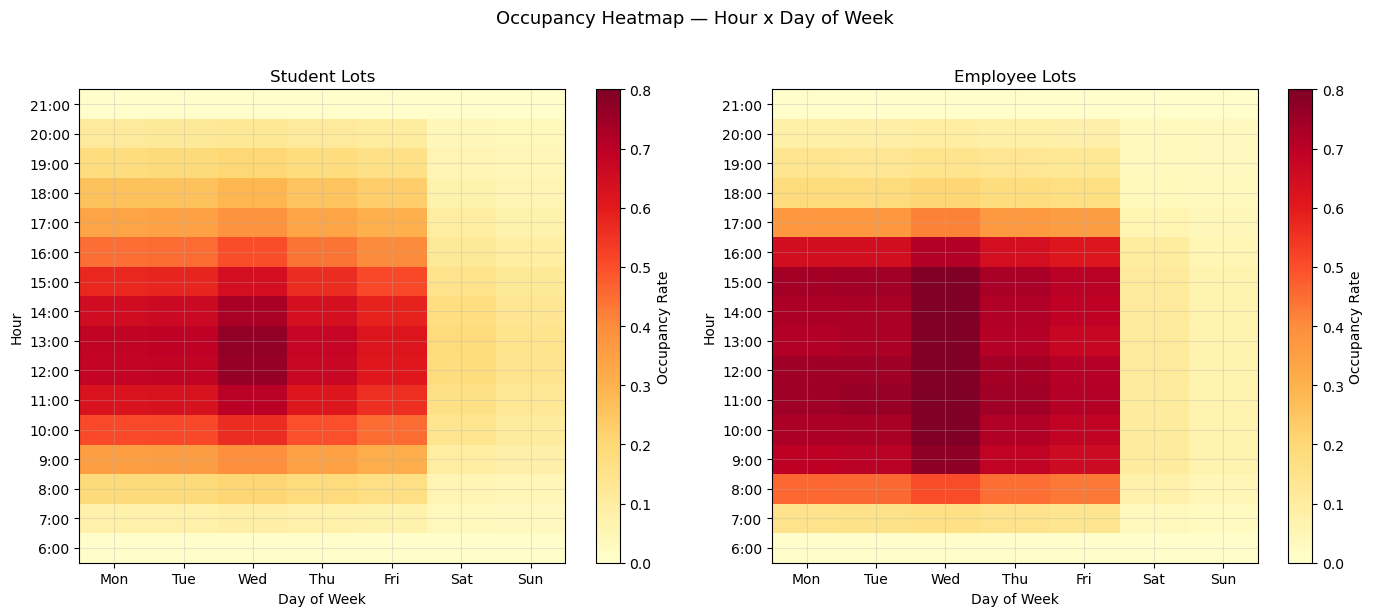

In [6]:
heatmap_op = df[(df["hour"] >= 6) & (df["hour"] <= 21)]
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, lot_type in zip(axes, ["Student", "Employee"]):
    subset = heatmap_op[heatmap_op["lot_type"] == lot_type]
    pivot = subset.pivot_table(
        values="occupancy_rate", index="hour", columns="day_of_week", aggfunc="mean"
    )

    im = ax.imshow(
        pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.8, origin="lower"
    )
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{h}:00" for h in pivot.index])
    ax.set_title(f"{lot_type} Lots")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Hour")
    plt.colorbar(im, ax=ax, label="Occupancy Rate")

plt.suptitle("Occupancy Heatmap — Hour x Day of Week", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()